# 01 — Collect Initial Datasets

This notebook builds the V1 feature table for one Estonian county (Lääne).

Each row in the output is a 1×1 km grid cell. The features will later feed into:
- A **simulator** that scores land-use actions (protect, restore wetland, afforest)
- A **neuroevolution optimizer** (NSGA-II) that evolves policies across these cells

## Data sources

| Source | What it provides | Auto? |
|--------|-----------------|-------|
| Statistics Estonia 1km grid | Base grid geometry + population per cell | ✅ auto-download |
| GADM | County boundary for spatial clipping | ✅ auto-download |
| CORINE Land Cover 2018 (100m raster) | Land cover proportions per cell | ❌ manual download |
| EELIS WFS | Protected area polygons | ✅ auto (web service) |
| OpenStreetMap (Geofabrik) | Roads and buildings | ✅ auto-download |

In [13]:
import sys
sys.path.insert(0, '../src')

import geopandas as gpd
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from estonia_landuse.data.constants import (
    DATA_RAW, DATA_PROCESSED, CRS_ESTONIAN, COUNTY_NAME,
    GADM_COUNTIES_URL, STAT_EE_GRID_URLS, STAT_EE_GRID_YEAR,
    CORINE_TIF, EELIS_WFS_URL, OSM_ESTONIA_GPKG_URL
)
from estonia_landuse.data.download import download_file, unzip
from estonia_landuse.data.load import (
    fetch_protected_areas_wfs, extract_clc_from_raster,
    compute_distance_to_nearest, load_osm_layer,
    compute_road_density, compute_building_density
)

DATA_RAW.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

print(f"Target county: {COUNTY_NAME}")
print(f"CORINE TIF exists: {CORINE_TIF.exists()}")

Target county: Lääne
CORINE TIF exists: True


## 1. Base Grid

**What:** Statistics Estonia publishes a 1×1 km INSPIRE grid covering all of Estonia.
Each cell has a population count (TOTAL_24 = population in 2024).

**Why:** This is our spatial unit of analysis. The neuroevolution optimizer will assign
one land-use action per cell. Population tells us where people live — high-population
cells have high opportunity cost and shouldn't be restored/afforested.

In [14]:
grid_url = STAT_EE_GRID_URLS[STAT_EE_GRID_YEAR]
grid_zip = download_file(grid_url, f"{STAT_EE_GRID_YEAR}_3301.zip", subdir="population_grid")
grid_dir = unzip(grid_zip)

shp_files = list(grid_dir.rglob("*.shp"))
grid = gpd.read_file(shp_files[0])
if grid.crs != CRS_ESTONIAN:
    grid = grid.to_crs(CRS_ESTONIAN)
print(f"Full Estonia grid: {len(grid)} cells")
grid.head()

Already exists: C:\Users\risto\projects\et-landuse-neuroevolution\data\raw\population_grid\2024_3301.zip
Already extracted: C:\Users\risto\projects\et-landuse-neuroevolution\data\raw\population_grid\2024_3301
Full Estonia grid: 45668 cells


,OBJECTID,GRD_INSPIR,TOTAL_24,geometry
0,1.0,1kmN6465E0369,0.0,"POLYGON ((369000 6465000, 369000 6466000, 3700..."
1,2.0,1kmN6466E0369,0.0,"POLYGON ((369000 6466000, 369000 6467000, 3700..."
2,3.0,1kmN6467E0369,0.0,"POLYGON ((369000 6467000, 369000 6468000, 3700..."
3,4.0,1kmN6468E0369,0.0,"POLYGON ((369000 6468000, 369000 6469000, 3700..."
4,5.0,1kmN6465E0370,0.0,"POLYGON ((370000 6465000, 370000 6466000, 3710..."


## 2. Clip to County

**What:** The grid covers all Estonia (~45k cells). We clip to Lääne County using
GADM administrative boundaries (spatial join).

**Why:** V1 scope is one county only. Lääne has a good mix of coast, wetlands, forests,
and protected areas — ideal for demonstrating conservation/restoration trade-offs.

In [15]:
counties = gpd.read_file(GADM_COUNTIES_URL).to_crs(CRS_ESTONIAN)
county_boundary = counties[counties["NAME_1"] == COUNTY_NAME]
print(f"Selected: {COUNTY_NAME}, area: {county_boundary.geometry.area.values[0]/1e6:.0f} km²")

# Spatial clip: keep cells that intersect the county boundary
county_grid = gpd.sjoin(grid, county_boundary[["geometry"]], how="inner", predicate="intersects")
county_grid = county_grid.drop(columns=["index_right"], errors="ignore").reset_index(drop=True)
county_grid["cell_id"] = range(len(county_grid))
print(f"County grid: {len(county_grid)} cells")

Selected: Lääne, area: 2428 km²
County grid: 2806 cells


## 3. Land Cover (CORINE 2018 raster)

**What:** For each 1km cell, we read all 100m CORINE pixels inside it and compute:
- The **dominant** land cover class (most frequent pixel value)
- The **proportion** of each land cover group: forest_pct, wetland_pct, agriculture_pct, etc.
- **Weighted scores** for naturalness and carbon based on proportions

**Why:** Land cover is the foundation of the simulator. Proportions are more informative
than just the dominant class because a cell that's 60% forest + 40% wetland should score
differently from a cell that's 100% forest. The simulator uses these to decide which
actions are feasible and how much biodiversity/carbon gain an action produces.

**Note:** The CORINE raster uses sequential pixel IDs (1–44), not the standard 3-digit
CLC codes. Our code translates them automatically.

In [16]:
if CORINE_TIF.exists():
    print(f"Processing {len(county_grid)} cells from {CORINE_TIF.name}...")
    county_grid = extract_clc_from_raster(county_grid, str(CORINE_TIF))
    print(f"\nDominant class distribution:")
    print(county_grid["land_cover_group"].value_counts())
    print(f"\nMean proportions across all cells:")
    pct_cols = [c for c in county_grid.columns if c.endswith('_pct')]
    print(county_grid[pct_cols].mean().sort_values(ascending=False))
else:
    print(f"CORINE TIF not found at: {CORINE_TIF}")
    print("Download the 100m raster from:")
    print("https://land.copernicus.eu/en/products/corine-land-cover/clc2018")

Processing 2806 cells from U2018_CLC2018_V2020_20u1.tif...

Dominant class distribution:
land_cover_group
forest         1489
agriculture     379
grassland       341
water           319
wetland         258
urban            20
Name: count, dtype: int64

Mean proportions across all cells:
forest_pct           0.513205
agriculture_pct      0.149832
grassland_pct        0.128766
water_pct            0.101048
wetland_pct          0.095481
urban_pct            0.009372
other_natural_pct    0.002295
dtype: float64


## 4. Protected Areas (EELIS WFS)

**What:** Fetches protected area polygons from Estonia's Environmental Register (EELIS)
public WFS service. Computes per cell:
- `protected_overlap_pct` — fraction of cell area covered by a protected area
- `distance_to_protected_m` — distance from cell centroid to nearest protected area

**Why:** These features drive the "protect" action and connectivity objectives.
Cells already inside or near protected areas are good candidates for protection
(improves habitat connectivity). Cells far from protected areas may be low-priority
for the "protect" action but good candidates for restoration.

In [17]:
bbox = tuple(county_grid.total_bounds)
try:
    protected = fetch_protected_areas_wfs(bbox, layer="eelis:kr_kaitseala")
    print(f"Got {len(protected)} protected area polygons")
except Exception as e:
    print(f"WFS error: {e}")
    protected = None

Got 61 protected area polygons


In [18]:
if protected is not None and not protected.empty:
    # Overlap: intersect protected areas with grid, measure area
    intersections = gpd.overlay(
        county_grid[["cell_id", "geometry"]], 
        protected[["geometry"]], how="intersection"
    )
    intersections["overlap_area"] = intersections.geometry.area
    cell_areas = county_grid.set_index("cell_id").geometry.area
    overlap = intersections.groupby("cell_id")["overlap_area"].sum()
    county_grid["protected_overlap_pct"] = county_grid["cell_id"].map(
        lambda cid: overlap.get(cid, 0) / cell_areas.get(cid, 1)
    ).clip(0, 1)
    
    # Distance to nearest protected area
    county_grid["distance_to_protected_m"] = compute_distance_to_nearest(county_grid, protected)
    
    print(f"Protected overlap: mean={county_grid['protected_overlap_pct'].mean():.3f}, "
          f"cells with any overlap: {(county_grid['protected_overlap_pct'] > 0).sum()}")
else:
    print("No protected areas data available")

Protected overlap: mean=0.284, cells with any overlap: 1202


## 5. Roads & Buildings (OpenStreetMap)

**What:** Downloads the OSM Estonia extract and computes per cell:
- `road_density_km` — total km of road inside the cell
- `building_count` — number of buildings inside the cell

**Why:** These are proxies for human pressure and economic activity.
- High road density → fragmented habitat, expensive to restore
- Many buildings → settled area, high opportunity cost, constraint against restoration

We use density/count rather than distance because at 1km resolution, almost every
cell is within 1km of a road. The amount of infrastructure *within* the cell is
more discriminating.

In [19]:
osm_zip = download_file(
    url=OSM_ESTONIA_GPKG_URL,
    filename="estonia-latest-free.shp.zip",
    subdir="osm"
)
osm_dir = unzip(osm_zip)
shp_files = list(osm_dir.rglob("*.shp"))
print(f"Available layers: {[f.stem for f in shp_files]}")

Already exists: C:\Users\risto\projects\et-landuse-neuroevolution\data\raw\osm\estonia-latest-free.shp.zip
Already extracted: C:\Users\risto\projects\et-landuse-neuroevolution\data\raw\osm\estonia-latest-free.shp
Available layers: ['gis_osm_adminareas_a_free_1', 'gis_osm_buildings_a_free_1', 'gis_osm_landuse_a_free_1', 'gis_osm_natural_a_free_1', 'gis_osm_natural_free_1', 'gis_osm_places_a_free_1', 'gis_osm_places_free_1', 'gis_osm_pofw_a_free_1', 'gis_osm_pofw_free_1', 'gis_osm_pois_a_free_1', 'gis_osm_pois_free_1', 'gis_osm_protected_areas_a_free_1', 'gis_osm_railways_free_1', 'gis_osm_roads_free_1', 'gis_osm_traffic_a_free_1', 'gis_osm_traffic_free_1', 'gis_osm_transport_a_free_1', 'gis_osm_transport_free_1', 'gis_osm_waterways_free_1', 'gis_osm_water_a_free_1']


In [20]:
# Road density (km of road per 1km² cell)
roads_file = next((f for f in shp_files if 'roads' in f.stem.lower()), None)
if roads_file:
    print(f"Loading {roads_file.name}...")
    roads = load_osm_layer(str(roads_file), county_grid)
    print(f"Roads in county: {len(roads)}")
    county_grid["road_density_km"] = compute_road_density(county_grid, roads)
    print(f"Road density: mean={county_grid['road_density_km'].mean():.2f} km/cell, "
          f"max={county_grid['road_density_km'].max():.1f}")

Loading gis_osm_roads_free_1.shp...
Roads in county: 15593
Road density: mean=1.40 km/cell, max=36.2


In [21]:
# Building count (proxy for settlement intensity)
buildings_file = next((f for f in shp_files if 'buildings' in f.stem.lower()), None)
if buildings_file:
    print(f"Loading {buildings_file.name}...")
    buildings = load_osm_layer(str(buildings_file), county_grid)
    print(f"Buildings in county: {len(buildings)}")
    county_grid["building_count"] = compute_building_density(county_grid, buildings)
    print(f"Buildings per cell: mean={county_grid['building_count'].mean():.1f}, "
          f"max={county_grid['building_count'].max():.0f}")

Loading gis_osm_buildings_a_free_1.shp...
Buildings in county: 46523
Buildings per cell: mean=11.8, max=1046


## 6. Save

Export the feature table in two formats:
- **GeoPackage** (.gpkg) — for mapping and GIS tools, includes geometry
- **Parquet** — for fast loading in Python/ML pipelines, no geometry

In [22]:
print(f"Final shape: {county_grid.shape}")
print(f"Columns: {list(county_grid.columns)}")

county_grid.to_file(DATA_PROCESSED / "base_grid.gpkg", driver="GPKG")
county_grid.drop(columns="geometry").to_parquet(DATA_PROCESSED / "features_v1.parquet", index=False)
print(f"\nSaved to {DATA_PROCESSED}")

Final shape: (2806, 20)
Columns: ['OBJECTID', 'GRD_INSPIR', 'TOTAL_24', 'geometry', 'cell_id', 'land_cover_class', 'land_cover_group', 'urban_pct', 'agriculture_pct', 'grassland_pct', 'forest_pct', 'wetland_pct', 'water_pct', 'other_natural_pct', 'naturalness_score', 'carbon_score', 'protected_overlap_pct', 'distance_to_protected_m', 'road_density_km', 'building_count']

Saved to C:\Users\risto\projects\et-landuse-neuroevolution\data\processed\v1


## 7. Maps

Visualize the spatial variation in key features.
These should show clear patterns — if everything looks uniform, something is wrong.

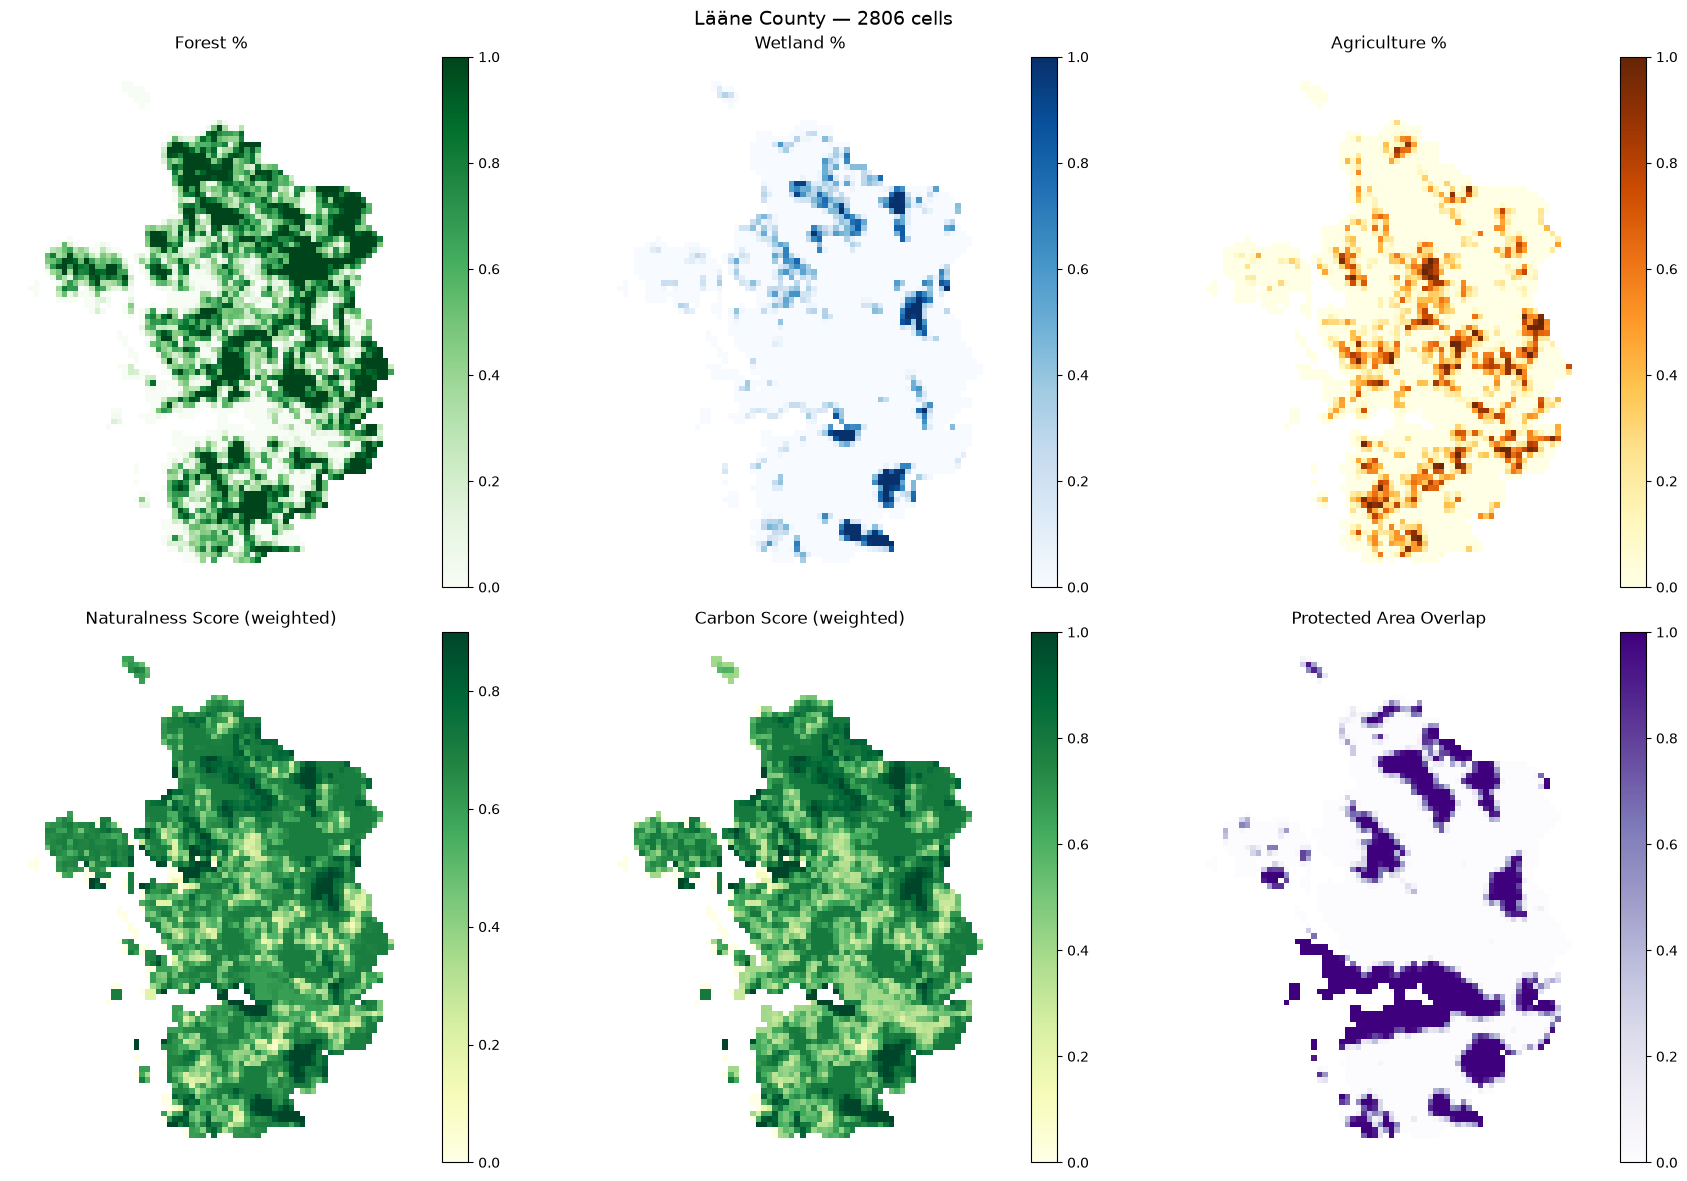

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

county_grid.plot(column="forest_pct", legend=True, ax=axes[0,0], cmap="Greens")
axes[0,0].set_title("Forest %")

county_grid.plot(column="wetland_pct", legend=True, ax=axes[0,1], cmap="Blues")
axes[0,1].set_title("Wetland %")

county_grid.plot(column="agriculture_pct", legend=True, ax=axes[0,2], cmap="YlOrBr")
axes[0,2].set_title("Agriculture %")

county_grid.plot(column="naturalness_score", legend=True, ax=axes[1,0], cmap="YlGn")
axes[1,0].set_title("Naturalness Score (weighted)")

county_grid.plot(column="carbon_score", legend=True, ax=axes[1,1], cmap="YlGn")
axes[1,1].set_title("Carbon Score (weighted)")

if "protected_overlap_pct" in county_grid.columns:
    county_grid.plot(column="protected_overlap_pct", legend=True, ax=axes[1,2], cmap="Purples")
    axes[1,2].set_title("Protected Area Overlap")

for ax in axes.flat:
    ax.set_axis_off()

plt.suptitle(f"{COUNTY_NAME} County — {len(county_grid)} cells", fontsize=14)
plt.tight_layout()
plt.show()

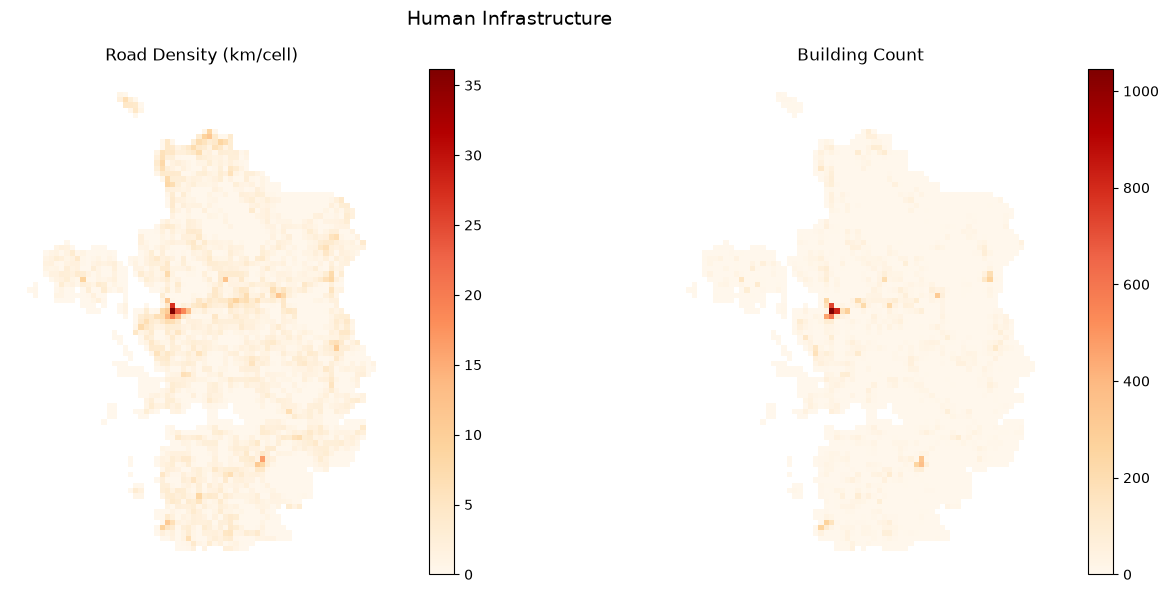

In [24]:
# Infrastructure maps
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

if "road_density_km" in county_grid.columns:
    county_grid.plot(column="road_density_km", legend=True, ax=axes[0], cmap="OrRd")
    axes[0].set_title("Road Density (km/cell)")

if "building_count" in county_grid.columns:
    county_grid.plot(column="building_count", legend=True, ax=axes[1], cmap="OrRd")
    axes[1].set_title("Building Count")

for ax in axes.flat:
    ax.set_axis_off()

plt.suptitle("Human Infrastructure", fontsize=14)
plt.tight_layout()
plt.show()